In [1]:
import numpy as np
L = 1.0  # 長さ
A = 0.1  # 断面積
k = 3.0  # 熱伝導率
Tb = 0.0 # 端点x(0)での規定温度  
qb = 3.0 # 端点x(L)での規定熱流束
Q = 6.0  # 熱源
n = 2    # 要素数
h = L/n  # 要素長
Ke = A*k/h*np.array([ # 要素熱伝導行列
    [1, -1],
    [-1, 1]]) 

In [2]:
ind_node = np.arange(n+1) # 節点番号
ind_elem = ind_node[:-1]  # 要素番号
ind_edge = ind_elem[:, None] + np.array([0, 1]) # 全体の局所節点番号

In [3]:
print(ind_edge)

[[0 1]
 [1 2]]


In [4]:
K = np.zeros((n+1, n+1))
for e in range(n):
    nodes = ind_edge[e]
    K[np.ix_(nodes, nodes)] += Ke

In [5]:
print(K)

[[ 0.6 -0.6  0. ]
 [-0.6  1.2 -0.6]
 [ 0.  -0.6  0.6]]


In [6]:
f = np.zeros(n+1)       
f[1] = A*k/h*Tb  # ディリクレ境界条件に関する項の挿入 
f[1:] += Q*h/2   # 熱源に関する項の足し合わせ
f[1:-1] += Q*h/2 # 熱源に関する項の重ね合わせ
f[-1] += -A*qb   # 熱流束に関する項の足し合わせ

In [7]:
print(f)

[0.  3.  1.2]


In [8]:
d = np.zeros(n+1)
d[1:] = np.linalg.solve(K[1:, 1:], f[1:]) # 未知である温度のみ計算
d[0] = Tb # ディリクレ境界条件の温度を設定

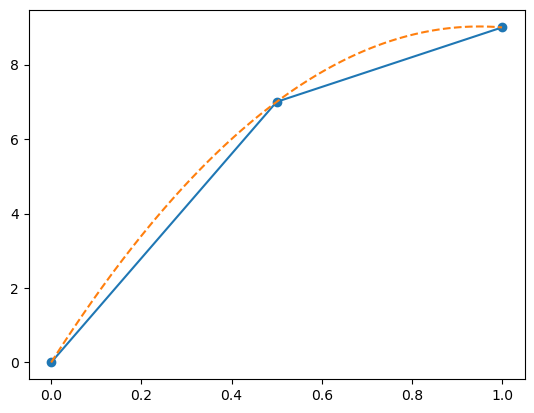

In [9]:
import matplotlib.pyplot as plt
x_p = np.linspace(0, L, n+1)
plt.plot(x_p, d, marker='o', linestyle='-')
x = np.linspace(0, L, 100)
Tex = -10*x**2 + 19*x
plt.plot(x, Tex, linestyle='--')

In [10]:
from scipy import sparse
sK = (Ke.flatten()[:, None]*np.ones(n)).flatten('F')
iK = np.repeat(ind_edge, 2, axis=0).flatten()
jK = np.repeat(ind_edge, 2, axis=1).flatten()
K = sparse.coo_matrix((sK, (iK, jK))).tocsc()

In [11]:
print(K)

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 7 stored elements and shape (3, 3)>
  Coords	Values
  (0, 0)	0.6000000000000001
  (1, 0)	-0.6000000000000001
  (0, 1)	-0.6000000000000001
  (1, 1)	1.2000000000000002
  (2, 1)	-0.6000000000000001
  (1, 2)	-0.6000000000000001
  (2, 2)	0.6000000000000001


In [12]:
from scipy.sparse import linalg as spla
d = np.zeros(n+1)
d[1:] = spla.spsolve(K[1:, 1:], f[1:]) # 未知である温度のみ計算
d[0] = Tb # ディリクレ境界条件の温度を設定

In [13]:
import numpy as np
import matplotlib.pyplot as plt
L1 = 1.0  # x方向長さ
L2 = 1.0  # y方向長さ
k = 3.0   # 熱伝導率
Tb = 0.0  # ディリクレ境界での規定温度
qb = 3.0  # ノイマン境界での規定熱流束
Q = 6.0   # 熱源
n1 = 2    # x方向要素数
n2 = 2    # y方向要素数
h = L1/n1 # 要素長
Ke = 1/6*np.array([ # 要素熱伝導行列/k
    [ 4, -1, -2, -1],
    [-1, 4, -1, -2],
    [-2, -1, 4, -1],
    [-1, -2, -1, 4]]) 

In [14]:
ind_node = np.arange((n1+1)*(n2+1)).reshape(n2+1, n1+1) # 節点番号
ind_elem = ind_node[:-1, :-1].ravel() # 要素番号
ind_edge = ind_elem[:, None] + np.array([0, 1, n1+2, n1+1]) # 全体の局所節点番号

In [15]:
print(ind_edge)

[[0 1 4 3]
 [1 2 5 4]
 [3 4 7 6]
 [4 5 8 7]]


In [16]:
from scipy import sparse
sK = sK = (Ke.flatten()[:, None]*k*np.ones(n1*n2)).flatten('F')
iK = np.repeat(ind_edge, 4, axis=0).flatten()
jK = np.repeat(ind_edge, 4, axis=1).flatten()
K = sparse.coo_matrix((sK, (iK, jK))).tocsc()

In [17]:
ind_fixed = np.arange(0, (n1+1)*(n2+1), n1+1)   # ディリクレ境界：左
ind_bound_neumann = np.concatenate([np.arange(1, n1+1), # ノイマン境界：下右上
                        np.arange(2*(n1+1)-1, (n1+1)*(n2+1), n1+1),
                        np.arange((n1+1)*n2+1, (n1+1)*(n2+1)-1)]) 
ind_inside = np.setdiff1d(np.arange((n1+1)*(n2+1)), # 境界を除く領域内部 
                          np.concatenate([ind_fixed, ind_bound_neumann]))
ind_bound_except_corners = np.setdiff1d(ind_bound_neumann, # 四隅を除く境界 
                                 [0, n1, n2*(n1+1), (n1+1)*(n2+1)-1])

In [18]:
f = np.zeros((n1+1)*(n2+1))
f -= np.sum(K.toarray()[ind_fixed, :]*Tb, axis=0) # ディリクレ境界条件の反映
f[ind_bound_neumann] += h**2*Q/4 # ノイマン境界上での熱源の足し合わせ
f[ind_bound_except_corners] += h**2*Q/4 # 四隅を除く境界上での熱源の重ね合わせ
f[ind_inside] += h**2*Q # 領域内部の熱源の足し合わせ
f[ind_bound_neumann] += h*qb # 熱流束の足し合わせ

In [19]:
from scipy.sparse import linalg as spla
d = np.zeros((n1+1)*(n2+1))
ind_free = np.setdiff1d(np.arange((n1+1)*(n2+1)), ind_fixed) # 計算対象節点
d[ind_free] = spla.spsolve(K[ind_free][:, ind_free], f[ind_free])
d[ind_fixed] = Tb # ディリクレ境界条件の温度を設定

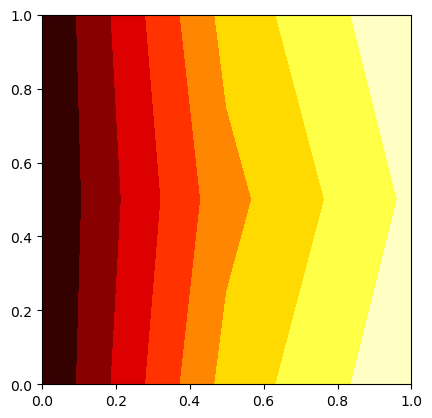

In [20]:
x_p, y_p = np.linspace(0, L1, n1+1), np.linspace(0, L2, n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, d.reshape((n2+1, n1+1)), cmap='hot')
plt.gca().set_aspect('equal')